In [5]:
# Importing necessary libraries
import requests
import base64
from PIL import Image
from io import BytesIO
import dotenv

In [6]:
from dotenv import load_dotenv
import os
load_dotenv()

api_key = os.getenv("STABILITY_API_KEY")

In [7]:
def generate_image_sd(prompt, size=1024):

    url = "https://api.stability.ai/v2beta/stable-image/generate/core"

    headers = {
        "Authorization": f"Bearer {api_key}",
        "Accept": "image/*"
    }

    files = {
        "prompt": (None, prompt),
        "width": (None, str(size)),
        "height": (None, str(size)),
        "output_format": (None, "png")
    }

    response = requests.post(url, headers=headers, files=files)

    if response.status_code != 200:
        raise Exception("API Error: " + response.text)

    image_bytes = response.content

    img = Image.open(BytesIO(image_bytes)).convert("RGBA")

    return [img]


In [8]:
prompt = (
    "A high-resolution cinematic photograph of a red fox in a mossy forest, "
    "golden hour lighting, shallow depth of field, Nikon 85mm style."
)


In [9]:
images = generate_image_sd(prompt)


In [10]:
for i, img in enumerate(images):
    img.save(f"sd_out_{i+1}.png")
    print("Saved sd_out_", i+1)


Saved sd_out_ 1


(np.float64(-0.5), np.float64(1535.5), np.float64(1535.5), np.float64(-0.5))

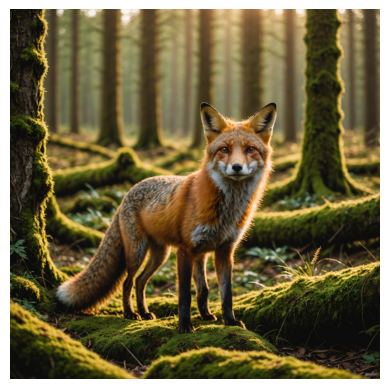

In [16]:
import matplotlib.pyplot as plt

image = generate_image_sd(prompt)

plt.imshow(image[0])
plt.axis("off")